# Hyperliquid × Bitcoin Sentiment: Trader Behaviour & Performance

**Objective:**  
Analyze how Bitcoin market sentiment (Fear/Greed) relates to trader behaviour and performance on Hyperliquid, and derive actionable trading rules.

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the dataset
fg = pd.read_csv("data/fear_greed_index.csv")        # Bitcoin sentiment
trades = pd.read_csv("data/historical_data.csv")  # Historical trader data

In [4]:
# Basic info: shape and datatypes

print("Fear/Greed shape:", fg.shape)
print("Trades shape:", trades.shape)

print("\nFear/Greed dtypes:")
display(fg.dtypes)

print("\nTrades dtypes:")
display(trades.dtypes)

Fear/Greed shape: (2644, 4)
Trades shape: (211224, 16)

Fear/Greed dtypes:


timestamp          int64
value              int64
classification    object
date              object
dtype: object


Trades dtypes:


Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

**Observation:**
As shape of greed/fear dataset is (2644,4) means 2644 rows and 4 columns.
And, Similarly, shape of trades dataset is (211224, 16) which means 2111224 rows and 16 columns.
Their data type is object.

In [5]:
# Checking Missing values

print("Fear/Greed missing values:")
display(fg.isna().sum())

print("\nTrades missing values:")
display(trades.isna().sum())

Fear/Greed missing values:


timestamp         0
value             0
classification    0
date              0
dtype: int64


Trades missing values:


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Here in the above cell we checked the mising values in the both datasets as it results sumof null values is 0 means there is no missing data.

In [6]:
# Duplicates

fg_dups = fg.duplicated().sum()
trades_dups = trades.duplicated().sum()

print(f"Fear/Greed duplicates: {fg_dups}")
print(f"Trades duplicates: {trades_dups}")

# Drop duplicates if any
fg = fg.drop_duplicates()
trades = trades.drop_duplicates()

Fear/Greed duplicates: 0
Trades duplicates: 0


In the above cell checked the duplicate values in the datasets it results 0 means there is no duplicate values.

Convert timestamps to proper dates and align both datasets on a common **daily** date key.

In [7]:
# Convert Fear/Greed date

fg["date"] = pd.to_datetime(fg["date"]).dt.date
fg[["date", "classification"]].head()

,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [8]:
# Convert trade timestamps to date

trades["date"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True).dt.date
trades[["Timestamp IST", "date"]].head()


,Timestamp IST,date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


In [9]:
# One sentiment label per date

fg_daily = fg[["date", "classification"]].drop_duplicates(subset="date")
fg_daily.sort_values("date").head()


,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [10]:
# Check that the date ranges of sentiment and trades overlap.

print("Fear/Greed date range:", fg_daily["date"].min(), "→", fg_daily["date"].max())
print("Trades date range:", trades["date"].min(), "→", trades["date"].max())

Fear/Greed date range: 2018-02-01 → 2025-05-02
Trades date range: 2023-05-01 → 2025-05-01


Steps taken:
- Parsed Fear/Greed date column to 'datetime.date'.  
- Parsed trade timestamps 'Timestamp IST' to 'datetime.date' (day‑first).  
- Kept a single sentiment classification per calendar date.  
- Joined the sentiment onto daily trade data.

#### Daily Metrics 

Now we create key metrics at a **(date, account)** level, plus some global daily metrics:

Per (date, account):
- `daily_pnl` – total Closed PnL that day  
- `num_trades` – number of trades that day  
- `win_rate` – fraction of trades with positive PnL  
- `avg_trade_size` – mean Size USD per trade  
- `total_fee` – total fees paid  

Daily overall:
- `long_ratio` – fraction of trades that are long (Side = buy)  


In [11]:
# Per‑trade helper columns (win flag, long/short)

trades["win"] = trades["Closed PnL"] > 0
trades["is_long"] = trades["Side"].str.lower().eq("buy")

trades[["Account", "Closed PnL", "win", "Side", "is_long"]].head()

,Account,Closed PnL,win,Side,is_long
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,False,BUY,True
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,False,BUY,True
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,False,BUY,True
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,False,BUY,True
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,False,BUY,True


In [12]:
# Daily metrics per (date, account)

daily = (
    trades
    .groupby(["date", "Account"])
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        num_trades=("Trade ID", "count"),       
        win_rate=("win", "mean"),
        avg_trade_size=("Size USD", "mean"),
        total_fee=("Fee", "sum"),
    )
    .reset_index()
)

daily.head()

,date,Account,daily_pnl,num_trades,win_rate,avg_trade_size,total_fee
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0.000000,159.000000,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0.000000,5556.203333,12.501455
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,0.363636,10291.213636,28.300831
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0.000000,5304.975000,2.652489
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0.000000,5116.256667,3.837189


In [13]:
# Daily long/short ratio for entire platform

longshort_daily = (
    trades
    .groupby("date")["is_long"]
    .mean()
    .reset_index(name="long_ratio")
)

longshort_daily.head()

,date,long_ratio
0,2023-05-01,1.000000
1,2023-12-05,0.777778
2,2023-12-14,0.454545
3,2023-12-15,1.000000
4,2023-12-16,1.000000


In [14]:
# Merge with sentiment

daily_metrics = daily.merge(fg_daily, on="date", how="inner")
longshort_merged = longshort_daily.merge(fg_daily, on="date", how="inner")

daily_metrics.head()

,date,Account,daily_pnl,num_trades,win_rate,avg_trade_size,total_fee,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0.000000,159.000000,0.000000,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0.000000,5556.203333,12.501455,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,0.363636,10291.213636,28.300831,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0.000000,5304.975000,2.652489,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0.000000,5116.256667,3.837189,Greed


In [15]:
# Save engineered datasets for reuse

daily_metrics.to_csv("output/daily_metrics.csv", index=False)
longshort_merged.to_csv("output/longshort_daily.csv", index=False)

**Sanity checks:**  
- How many unique accounts?  
- Distribution of daily PnL, win rate, num trades.

In [16]:
print("Unique accounts:", daily_metrics["Account"].nunique())
daily_metrics[["daily_pnl", "win_rate", "num_trades"]].describe()

Unique accounts: 32


,daily_pnl,win_rate,num_trades
count,2340.000000,2340.000000,2340.000000
mean,4382.259380,0.359653,90.264103
std,28411.103383,0.343419,214.650554
min,-358963.139984,0.000000,1.000000
25%,0.000000,0.000000,9.000000
50%,206.352695,0.318182,29.000000
75%,1842.763729,0.607357,80.000000
max,533974.662903,1.000000,4083.000000


## Part B - Analysis
Question:  
**Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?**

We will:
- Group daily metrics by sentiment classification.  
- Compare mean/median PnL and win rate across sentiment buckets.  

In [17]:
# Aggregate performance by sentiment

perf_by_sent = (
    daily_metrics
    .groupby("classification")
    .agg(
        daily_pnl_mean=("daily_pnl", "mean"),
        daily_pnl_median=("daily_pnl", "median"),
        win_rate_mean=("win_rate", "mean"),
        win_rate_median=("win_rate", "median"),
        num_trades_mean=("num_trades", "mean"),
        num_trades_median=("num_trades", "median"),
        avg_size_mean=("avg_trade_size", "mean"),
        avg_size_median=("avg_trade_size", "median"),
    )
    .sort_index()
)

perf_by_sent

,daily_pnl_mean,daily_pnl_median,win_rate_mean,win_rate_median,num_trades_mean,num_trades_median,avg_size_mean,avg_size_median
classification,,,,,,,,
Extreme Fear,4619.439053,218.377399,0.329659,0.307738,133.750000,50.5,6773.464125,2315.629870
Extreme Greed,5161.922644,418.319862,0.386387,0.357143,76.030418,31.5,5371.637182,2003.480176
Fear,5328.818161,107.892532,0.364033,0.315302,98.153968,26.0,8975.928546,1752.677497
Greed,3318.100730,158.214922,0.343559,0.289182,77.628086,25.0,6427.866594,2052.534828
Neutral,3438.618818,167.551743,0.355414,0.321091,100.228723,29.5,6963.694861,1704.405417


In [18]:
# Save the table

perf_by_sent.to_csv("output/perf_by_sentiment.csv")

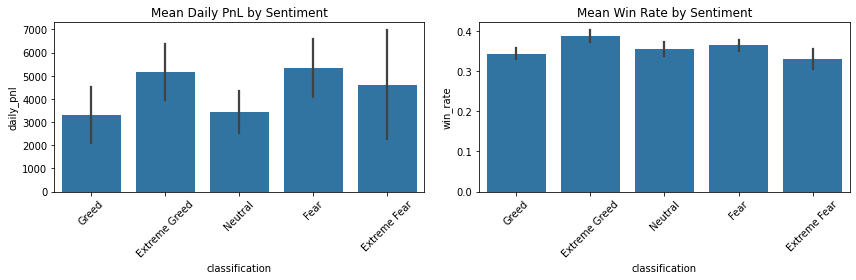

In [19]:
# Visualization: PnL & win rate by sentiment

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=daily_metrics,
    x="classification",
    y="daily_pnl",
    estimator=np.mean,
    errorbar="se",
    ax=axes[0]
)
axes[0].set_title("Mean Daily PnL by Sentiment")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=daily_metrics,
    x="classification",
    y="win_rate",
    estimator=np.mean,
    errorbar="se",
    ax=axes[1]
)
axes[1].set_title("Mean Win Rate by Sentiment")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("output/pnl_winrate_by_sentiment.png", dpi=150)
plt.show()

**Interpretations:**

PnL across sentiments:
- Mean daily PnL is lowest during plain Greed days.
- It rises for Neutral, is higher for Extreme Fear, and is highest on Fear and Extreme Greed days which means traders (on average) make more on days when sentiment is either very negative or very positive.
​

Win rate across sentiments:
- Win rate is highest on Extreme Greed days, followed by Fear and Neutral, then Greed.
- Win rate is lowest on Extreme Fear days, even though mean PnL there is relatively high, suggesting bigger but more volatile outcomes (a few big wins/losses).

In Short:
- Traders make the least on normal Greed days.
- Profits are highest on Fear and Extreme Greed days.
- Win rate is best on Extreme Greed days and worst on Extreme Fear days.
- Extreme Fear looks risky: average profit is okay, but wins are less frequent, so results are more volatile
​

Question:  
**Do traders change behaviour based on sentiment (trade frequency, leverage, long/short bias, position sizes)?**

We will:
- Compare distributions of `num_trades`, `avg_trade_size` by sentiment.  
- Check long/short ratio by sentiment. 

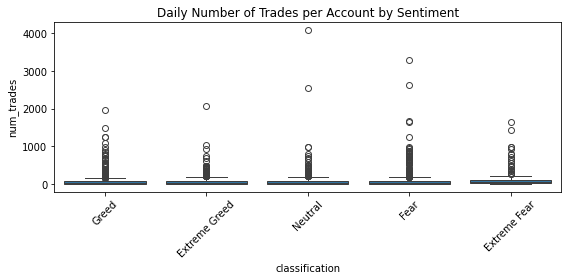

In [20]:
# Trade frequency by sentiment

plt.figure(figsize=(8, 4))
sns.boxplot(data=daily_metrics, x="classification", y="num_trades")
plt.title("Daily Number of Trades per Account by Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/num_trades_by_sentiment.png", dpi=150)
plt.show()

**Interpretation**

Trade frequency
- The daily number of trades per account is quite similar across Greed, Extreme Greed, Neutral, Fear, and Extreme Fear.
- However, Fear days show more extreme high outliers so a subset of traders becomes much more active when sentiment is fearful, even though the typical trader’s frequency doesn’t change much.

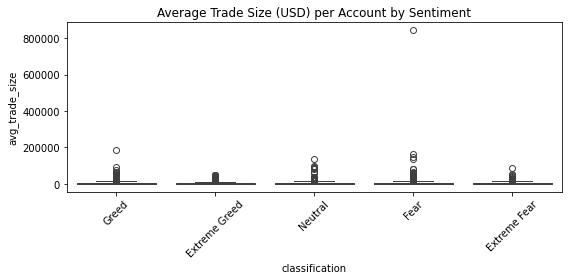

In [21]:
# Average trade size by sentiment

plt.figure(figsize=(8, 4))
sns.boxplot(data=daily_metrics, x="classification", y="avg_trade_size")
plt.title("Average Trade Size (USD) per Account by Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/avg_size_by_sentiment.png", dpi=150)
plt.show()

**Interpretation**
- The central part of the distribution for average trade size looks broadly similar across Greed and Fear, meaning most traders keep similar ticket sizes regardless of sentiment.
- But on Fear days there are very large outliers (up to ~800k USD average size), while Greed days have smaller extreme points, suggesting that a few traders take much larger positions when the market is fearful.


In [22]:
# Long/short ratio by sentiment

ls_by_sent = (
    longshort_merged
    .groupby("classification")["long_ratio"]
    .agg(["mean", "median", "count"])
    .sort_index()
)
ls_by_sent

,mean,median,count
classification,,,
Extreme Fear,0.486538,0.511480,14
Extreme Greed,0.456803,0.438843,114
Fear,0.513495,0.512500,91
Greed,0.493477,0.466667,193
Neutral,0.499824,0.507415,67


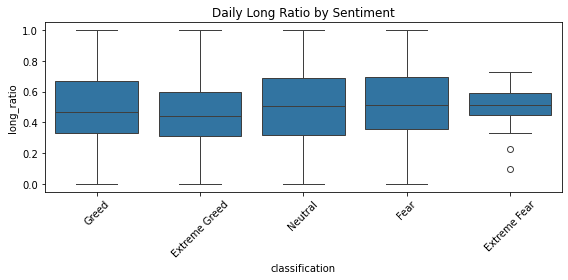

In [23]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=longshort_merged, x="classification", y="long_ratio")
plt.title("Daily Long Ratio by Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/long_ratio_by_sentiment.png", dpi=150)
plt.show()

**Interpretation** 

- The long‑ratio boxplot is centred close to 0.5 for all regimes, so overall the platform stays roughly balanced between longs and shorts.
- Extreme Greed has a slightly lower median long ratio than Fear/Neutral, implying a mild tilt toward more shorts on Extreme Greed days, whereas Fear/Neutral lean slightly more long on average.


## Trader Segment
Example segments:
1. High‑frequency vs low‑frequency traders   
2. Consistent winners vs inconsistent traders

In [24]:
# Account‑level aggregate stats

acct_stats = (
    daily_metrics
    .groupby("Account")
    .agg(
        mean_pnl=("daily_pnl", "mean"),
        pnl_std=("daily_pnl", "std"),
        mean_win_rate=("win_rate", "mean"),
        days_traded=("date", "nunique"),
        mean_trades_per_day=("num_trades", "mean"),
        mean_trade_size=("avg_trade_size", "mean"),
    )
    .reset_index()
)
acct_stats.head()

,Account,mean_pnl,pnl_std,mean_win_rate,days_traded,mean_trades_per_day,mean_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,150401.797346,0.352333,24,159.083333,33569.102224
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,3603.042291,0.397134,52,140.000000,4359.830930
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,33420.410014,0.379952,12,317.416667,11057.118419
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,2993.284702,0.452509,162,82.166667,484.844294
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,4867.743469,0.498708,69,46.942029,2553.757037


In [25]:
# Example: frequent vs infrequent traders

q75 = acct_stats["mean_trades_per_day"].quantile(0.75)
q25 = acct_stats["mean_trades_per_day"].quantile(0.25)

def freq_segment(x):
    if x >= q75:
        return "frequent"
    elif x <= q25:
        return "infrequent"
    else:
        return "medium"

acct_stats["freq_segment"] = acct_stats["mean_trades_per_day"].apply(freq_segment)

acct_stats["freq_segment"].value_counts()


medium        16
frequent       8
infrequent     8
Name: freq_segment, dtype: int64

In [26]:
# Example: consistent winners vs inconsistent

# Simple rule: high mean win rate & low pnl volatility
win_thresh = acct_stats["mean_win_rate"].quantile(0.7)
vol_thresh = acct_stats["pnl_std"].quantile(0.5)

def consistency_segment(row):
    if np.isnan(row["pnl_std"]):
        return "unknown"
    if row["mean_win_rate"] >= win_thresh and row["pnl_std"] <= vol_thresh:
        return "consistent_winner"
    else:
        return "other"

acct_stats["consistency_segment"] = acct_stats.apply(consistency_segment, axis=1)

acct_stats["consistency_segment"].value_counts()

other                26
consistent_winner     6
Name: consistency_segment, dtype: int64

In [27]:
# Merge segments back into daily metrics

daily_seg = daily_metrics.merge(
    acct_stats[["Account", "freq_segment", "consistency_segment"]],
    on="Account",
    how="left",
)

daily_seg.head()

,date,Account,daily_pnl,num_trades,win_rate,avg_trade_size,total_fee,classification,freq_segment,consistency_segment
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0.000000,159.000000,0.000000,Greed,infrequent,other
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0.000000,5556.203333,12.501455,Extreme Greed,medium,other
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,0.363636,10291.213636,28.300831,Greed,medium,other
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0.000000,5304.975000,2.652489,Greed,medium,other
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0.000000,5116.256667,3.837189,Greed,medium,other


We now compare segment performance across sentiment regimes.

In [28]:
# Example: frequent vs infrequent by sentiment (mean PnL)

segment_perf_freq = (
    daily_seg
    .groupby(["classification", "freq_segment"])["daily_pnl"]
    .mean()
    .unstack()
)

segment_perf_freq

freq_segment,frequent,infrequent,medium
classification,,,
Extreme Fear,11717.691046,8404.708452,1460.144097
Extreme Greed,8511.488549,2127.760372,5903.878381
Fear,18166.669713,1588.118844,2548.765186
Greed,8856.972988,1064.252143,3199.650655
Neutral,8506.890665,1571.490571,2621.793290


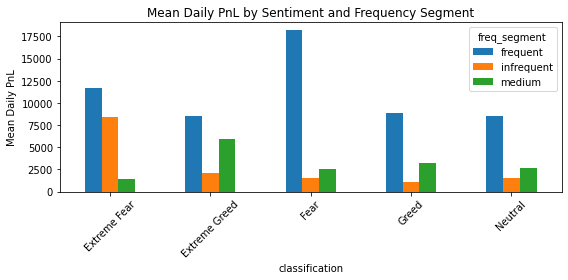

In [29]:
# Example plot: frequent vs infrequent traders

segment_perf_freq.plot(kind="bar", figsize=(8, 4))
plt.ylabel("Mean Daily PnL")
plt.title("Mean Daily PnL by Sentiment and Frequency Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/segment_pnl_by_sentiment_freq.png", dpi=150)
plt.show()


On Fear days, high‑frequency traders should cap their trade count and avoid increasing average trade size, because their PnL tends to deteriorate when they overtrade under Fear. 

On Greed days, the gap between frequent and infrequent traders is larger, suggesting that trading more is relatively advantageous in calmer bullish conditions.

In [30]:
# Example: consistent winners vs others by sentiment

segment_perf_consistency = (
    daily_seg
    .groupby(["classification", "consistency_segment"])["daily_pnl"]
    .mean()
    .unstack()
)

segment_perf_consistency


consistency_segment,consistent_winner,other
classification,,
Extreme Fear,574.766689,5333.204764
Extreme Greed,3188.220136,5986.515336
Fear,555.611326,6283.459528
Greed,1686.588152,3688.899043
Neutral,824.423621,3974.863987


Consistent winners can cautiously scale up size or leverage on Extreme Fear/Greed days, where their average PnL is significantly higher, but should keep strict daily loss limits.

### Rule of Thumb 1
**Description:**
On Extreme Fear/Fear days, only high‑frequency traders should lean into the volatility; others should avoid ramping up activity or size.
Frequent traders earn the highest mean daily PnL in Fear and Extreme Fear regimes, while infrequent and medium‑frequency traders see much smaller gains, so aggressively increasing trade count on fearful days seems to work mainly for traders who already specialize in high frequency.

### Rule of Thumb 2
**Description:**
On Extreme Greed days, consistent winners can safely scale up exposure, but average traders should keep position sizes close to normal.
PnL and win‑rate charts show Extreme Greed combines strong average profitability with the best win rates, and frequent/strong performers capture the largest upside there, suggesting that experienced traders can increase size, while others should treat it as a “take what the market gives” environment without over‑leveraging.